# Project Assignment 3: Yahoo Finance ( Transforms + Groups + Visuals)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv('../data/stock_details_5_years.csv')


df.head()
# print(df.head(3))
# print(df.tail(2))
# df.info()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits,Company
0,2018-11-29 00:00:00-05:00,43.829761,43.863354,42.639594,43.083508,167080000,0.00,0.0,AAPL
1,2018-11-29 00:00:00-05:00,104.769074,105.519257,103.534595,104.636131,28123200,0.00,0.0,MSFT
2,2018-11-29 00:00:00-05:00,54.176498,55.007500,54.099998,54.729000,31004000,0.00,0.0,GOOGL
3,2018-11-29 00:00:00-05:00,83.749496,84.499496,82.616501,83.678497,132264000,0.00,0.0,AMZN
4,2018-11-29 00:00:00-05:00,39.692784,40.064904,38.735195,39.037853,54917200,0.04,0.0,NVDA


## A. Data Card

- **Source:** Yahoo Finance CSV (`stock_details_5_years.csv`). 
- **Shape & Columns:** ~603k rows, 9 columns: Date, Open, High, Low, Close, Volume, Dividends, Stock Splits, Company. 
- **Units:** USD for prices & dividends; shares for Volume. 
- **Coverage window:** 2018-11-29 to 2023-11-29 (~5 years). 
- **Key ID:** (Company, Date). 
- **Missingness:** No nulls in the 9 columns (dividends & splits are sparse with many zeros). 
- **Known quirks:** Date may load as string; parse to datetime for time ops. 

In [26]:
dc = {}
dc["shape"] = df.shape
dc["cols"]  = df.columns.tolist()
dc["nulls"] = df.isna().sum().to_dict()


# parse Date for later steps; keep UTC like PA2
df["Date"] = pd.to_datetime(df["Date"], utc=True, errors="coerce")


dc["date_min"] = df["Date"].min()
dc["date_max"] = df["Date"].max()
dc

{'shape': (602962, 9),
 'cols': ['Date',
  'Open',
  'High',
  'Low',
  'Close',
  'Volume',
  'Dividends',
  'Stock Splits',
  'Company'],
 'nulls': {'Date': 0,
  'Open': 0,
  'High': 0,
  'Low': 0,
  'Close': 0,
  'Volume': 0,
  'Dividends': 0,
  'Stock Splits': 0,
  'Company': 0},
 'date_min': Timestamp('2018-11-29 05:00:00+0000', tz='UTC'),
 'date_max': Timestamp('2023-11-29 05:00:00+0000', tz='UTC')}

## B. Transformations (pandas):

- Reuse PA2 transforms; add at least one new categorical bucket or boolean mask that improves a visual (e.g., "high_income = Wealth ≥ 90th pct").
- Comment why each transform is needed for the figure (clarity, comparability, fairness).

In [27]:
# Boolean mask: did the day close higher than it opened?
# clarity: lets us compare positive vs negative days quickly
df["Gain"] = df["Close"] > df["Open"]


# Map: weekday name from Date
# comparability: lets us compare behavior by day-of-week
weekday_map = {0:"Monday",1:"Tuesday",2:"Wednesday",3:"Thursday",4:"Friday",5:"Saturday",6:"Sunday"}
df["Day_Name"] = df["Date"].dt.dayofweek.map(weekday_map)


# Row-wise apply: more descriptive daily outcome
# fairness/interpretability: tri-level (Gain / Loss / Break Even)
def stock_move(row):
   if row["Close"] > row["Open"]:
       return "Gain"
   elif row["Close"] < row["Open"]:
       return "Loss"
   else:
       return "Break Even"
df["Stock_Move"] = df.apply(stock_move, axis=1)


# Categorical bucketing: volume bands
# clarity: groups trading activity to compare distributions cleanly
volume_bins   = [0, 1e7, 5e7, 1e8, 5e8, np.inf]
volume_labels = ["Low", "Medium", "High", "Very High", "Extreme"]
df["Volume_Bucket"] = pd.cut(df["Volume"], bins=volume_bins, labels=volume_labels)


# Missing-data handling: dividends to 0 (dataset mostly zeros already)
# consistency: keeps type numeric, avoids NaN bar/violin gaps later
df["Dividends"] = df["Dividends"].fillna(0)


df[["Gain","Day_Name","Stock_Move","Volume_Bucket","Dividends"]].head()

,Gain,Day_Name,Stock_Move,Volume_Bucket,Dividends
0,False,Thursday,Loss,Very High,0.00
1,False,Thursday,Loss,Medium,0.00
2,True,Thursday,Gain,Medium,0.00
3,False,Thursday,Loss,Very High,0.00
4,False,Thursday,Loss,High,0.04


In [28]:
# 1) value_counts with a brief interpretation
company_counts = df["Company"].value_counts()
print("Top 5 companies by record count:\n", company_counts.head(), "\n")
print("Bottom 5 companies by record count:\n", company_counts.tail())


# 2) groupby aggregations
# a) highest average closing price across the window
avg_close = df.groupby("Company")["Close"].mean().sort_values(ascending=False)
print("\nTop 10 by average Close:\n", avg_close.head(10))


# b) count of gain days by company (multi-agg example)
gain_rate = (
   df.groupby("Company")
     .agg(days=("Gain","size"), gains=("Gain","sum"))
     .assign(gain_pct=lambda x: 100*x["gains"]/x["days"])
     .sort_values("gain_pct", ascending=False)
)
print("\nTop 10 companies by % Gain days:\n", gain_rate.head(10))  # new group by , others are resused from PA2

Top 5 companies by record count:
 Company
AAPL     1258
MSFT     1258
GOOGL    1258
AMZN     1258
NVDA     1258
Name: count, dtype: int64 

Bottom 5 companies by record count:
 Company
HLN     341
MBLY    275
GEHC    240
KVUE    145
ARM      54
Name: count, dtype: int64

Top 10 by average Close:
 Company
NVR      4369.628335
BKNG     2126.469873
AZO      1645.242242
CMG      1324.551017
MTD      1107.243361
MELI     1032.793749
FCNCA     701.952234
EQIX      639.148790
BLK       605.044845
REGN      567.637695
Name: Close, dtype: float64

Top 10 companies by % Gain days:
          days  gains   gain_pct
Company                        
GIB      1258    730  58.028617
ACN      1258    699  55.564388
CEG       469    259  55.223881
AJG      1258    690  54.848967
RELX     1258    689  54.769475
TRI      1258    689  54.769475
HD       1258    685  54.451510
ACGL     1258    685  54.451510
AAPL     1258    684  54.372019
TEAM     1258    683  54.292528


## C. Visuals (Seaborn):

- Regression view: lmplot (document ci choice, order, and any filtering).
- Small multiples: relplot/catplot with col=/row=/col_wrap and shared axes.
- Categorical distribution: catplot(kind="box" | "violin" | "swarm" | "strip"); label axes and units.
- Titles, axis labels, readable ticks, and a one-line caption under each figure.

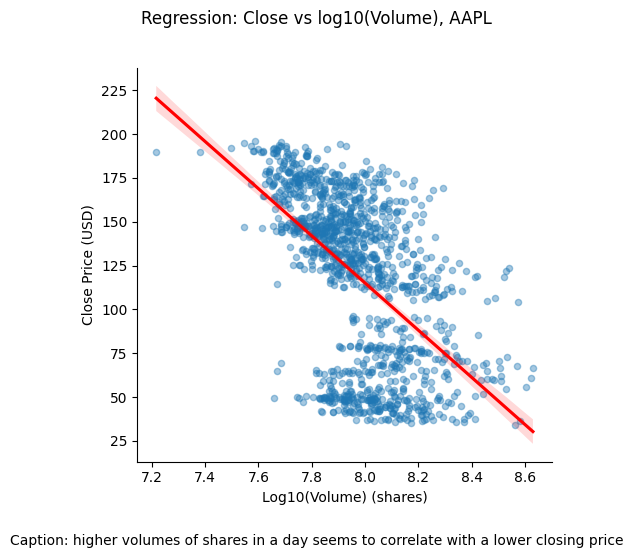

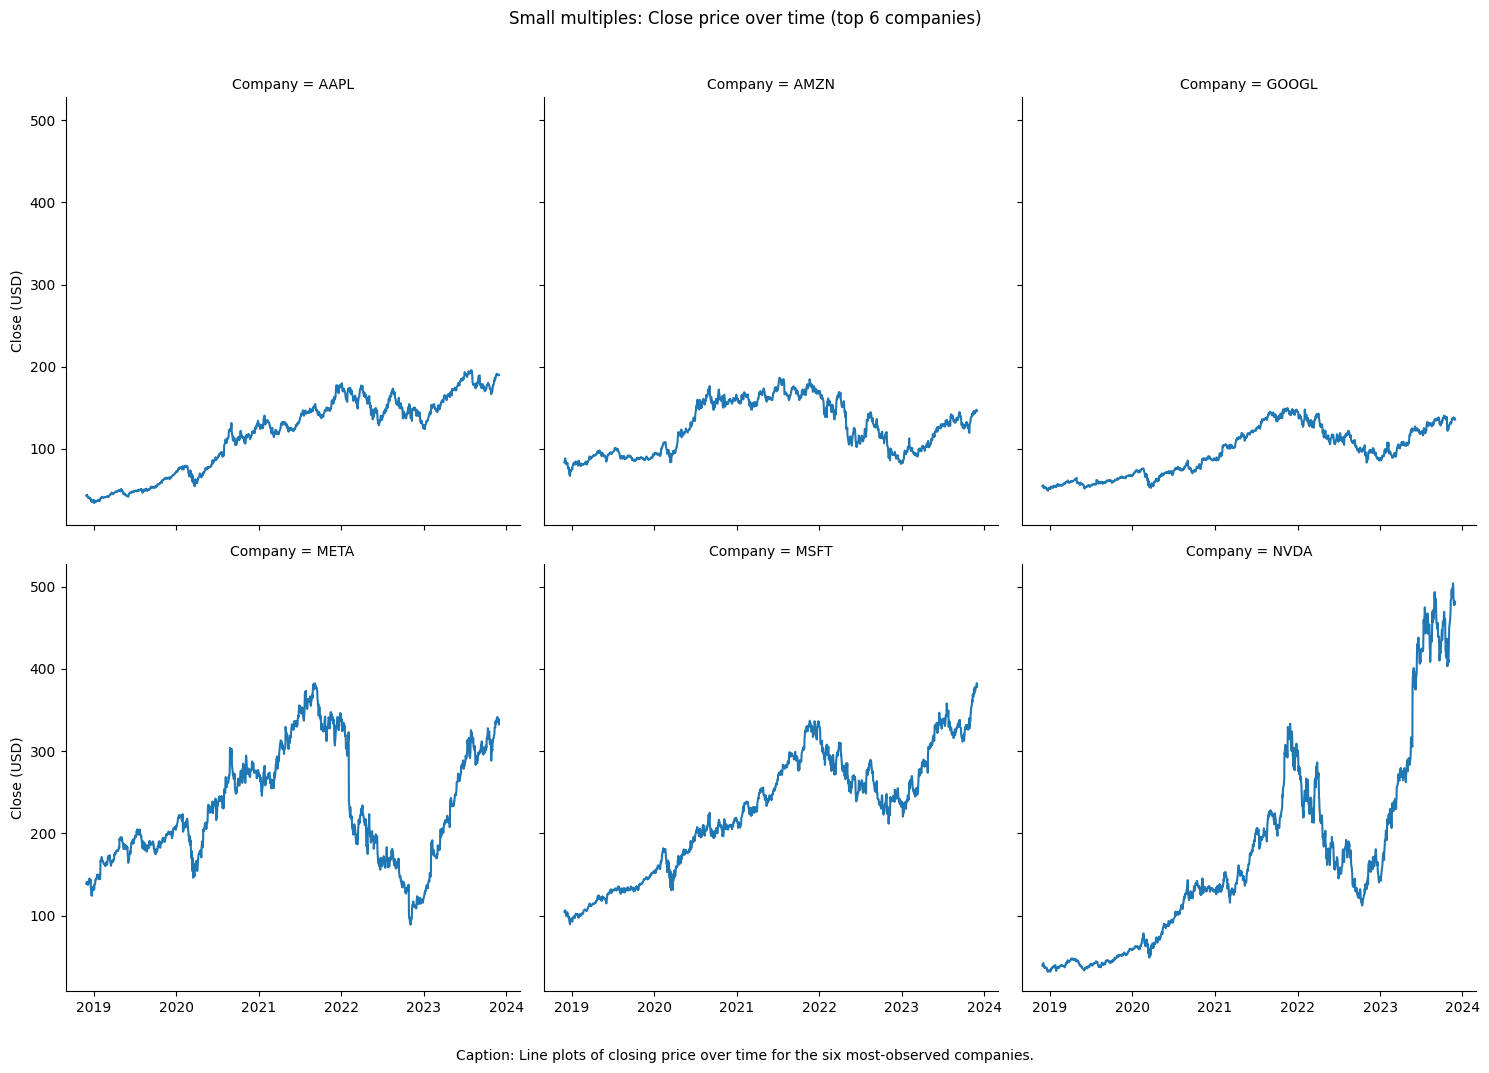

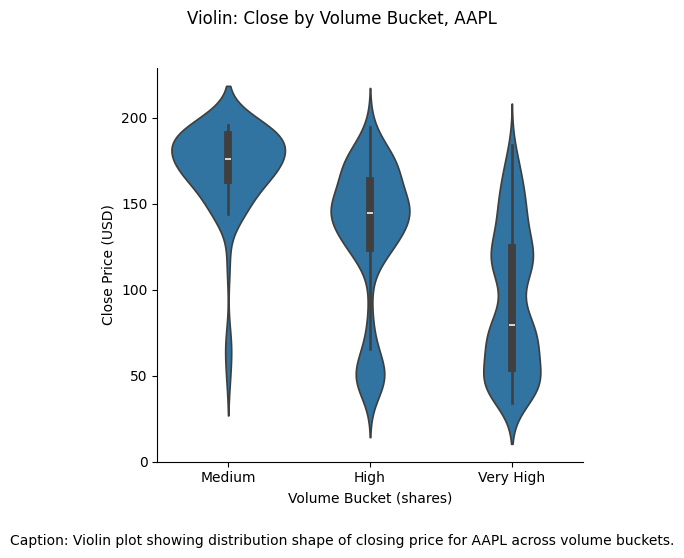

In [29]:
# REGRESSION PLOT


# fetch information for AAPL, top company
df_top = df[df["Company"] == "AAPL"].copy()
df_top["Log_Volume"] = np.log10(df_top["Volume"])


g = sns.lmplot(
   data = df_top,
   x = "Log_Volume",
   y = "Close",
   scatter_kws = {"alpha": 0.4, "s": 20},
   line_kws = {"color": "red"},
   ci = 95
)


g.fig.suptitle(f"Regression: Close vs log10(Volume), AAPL", y = 1.02)
g.set_axis_labels("Log10(Volume) (shares)", "Close Price (USD)")
g.fig.text(0.5, -0.05, "Caption: higher volumes of shares in a day seems to correlate with a lower closing price", ha = "center")
plt.tight_layout()


# SMALL MULTIPLES


# top 6 companies by record count
top6 = df["Company"].value_counts().head(6).index.tolist()
df6 = df[df["Company"].isin(top6)].sort_values(["Company", "Date"])


mults = sns.relplot(
   data = df6,
   x = "Date",
   y = "Close",
   kind = "line",
   col = "Company",
   col_wrap = 3
)


mults.fig.suptitle("Small multiples: Close price over time (top 6 companies)", y = 1.02)
for ax in mults.axes.flatten():
   ax.set_xlabel("")
   ax.set_ylabel("Close (USD)")
mults.fig.text(0.5, -0.03, "Caption: Line plots of closing price over time for the six most-observed companies.", ha = "center")
plt.tight_layout()


# VIOLIN PLOT
g_violin = sns.catplot(data = df_top, x = "Volume_Bucket", y = "Close", kind = "violin", order = ["Medium", "High", "Very High"])
g_violin.fig.suptitle(f"Violin: Close by Volume Bucket, AAPL", y = 1.02)
g_violin.set_axis_labels("Volume Bucket (shares)", "Close Price (USD)")
g_violin.fig.text(0.5, -0.05, "Caption: Violin plot showing distribution shape of closing price for AAPL across volume buckets.", ha = "center")
plt.tight_layout()

## D. (Optional) Statistical check:

- linregress (slope, intercept, p-value, R²) printed and briefly interpreted.

In [30]:
from scipy import stats


x = df_top["Log_Volume"].to_numpy()
y = df_top["Close"].to_numpy()


res = stats.linregress(x, y)


slope = res.slope
intercept = res.intercept
rvalue = res.rvalue
r2 = rvalue ** 2 if np.isfinite(rvalue) else np.nan
p_value = res.pvalue
std_err = res.stderr


print("Linregress results:")
print(f"n = {len(x)}")
print(f"slope = {slope:.6f}")
print(f"intercept = {intercept:.6f}")
print(f"r-value = {rvalue:.6f}  (R^2 = {r2:.4f})")
print(f"p-value = {p_value:.4g}")
print(f"std_err = {std_err:.6f}")


print("Interpretation: Slope is statistically significant at alpha = 0.05. There is evidence of association between the log(10) of volume and the close price in the sample.")

Linregress results:
n = 1258
slope = -134.608075
intercept = 1191.934066
r-value = -0.549335  (R^2 = 0.3018)
p-value = 4.4e-100
std_err = 5.777489
Interpretation: Slope is statistically significant at alpha = 0.05. There is evidence of association between the log(10) of volume and the close price in the sample.
